In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV

import warnings
warnings.filterwarnings('ignore')

df_original = pd.read_parquet('../Imdb_Movie_Dataset.parquet')
df = df_original.copy()

df = df[df['vote_count'] >= 10].copy()

df['sucesso'] = (df['vote_average'] >= 7.0).astype(int)

print("✅ Dados carregados! Total de filmes para análise:", len(df))

✅ Dados carregados! Total de filmes para análise: 78678


In [65]:
df['genres_limpo'] = df['genres'].astype(str).str.replace(r'[\(\)\[\]\']', '', regex=True).str.replace(' ', '')
df_genres = df['genres_limpo'].str.get_dummies(sep=',').add_prefix('genero_')

top_idiomas = df['original_language'].value_counts().head(5).index
df['idioma_agrupado'] = df['original_language'].where(df['original_language'].isin(top_idiomas), 'outros')
df_idiomas = pd.get_dummies(df['idioma_agrupado'], prefix='idioma', dtype=int)

df['pais_principal'] = df['production_countries'].astype(str).str.split(',').str[0].str.replace(r'[\(\)\[\]\']', '', regex=True)
top_paises = df['pais_principal'].value_counts().head(5).index
df['pais_agrupado'] = df['pais_principal'].where(df['pais_principal'].isin(top_paises), 'outros')
df_paises = pd.get_dummies(df['pais_agrupado'], prefix='pais', dtype=int)

df['tem_tagline'] = df['tagline'].notnull().astype(int)
df['tamanho_sinopse'] = df['overview'].fillna('').str.len()

df['mes_lancamento'] = pd.to_datetime(df['release_date'], format='mixed', errors='coerce').dt.month.fillna(0)

pistas_numericas = df[['runtime', 'budget', 'mes_lancamento', 'tem_tagline', 'tamanho_sinopse']]

X = pd.concat([pistas_numericas, df_genres, df_idiomas, df_paises], axis=1)
y = df['sucesso']

print("✅ Features criadas! Sazonalidade (Mês) adicionada com sucesso. Tamanho do X:", X.shape)

✅ Features criadas! Sazonalidade (Mês) adicionada com sucesso. Tamanho do X: (78678, 36)


In [66]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train = X_train.apply(pd.to_numeric, errors='coerce').fillna(0)
X_test = X_test.apply(pd.to_numeric, errors='coerce').fillna(0)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Dados divididos e escalonados! (SMOTE removido. Testaremos o class_weight)")

✅ Dados divididos e escalonados! (SMOTE removido. Testaremos o class_weight)


In [67]:
param_lr = {'C': [0.01, 0.1, 1, 10]}
grid_lr = GridSearchCV(LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000), param_lr, cv=3, scoring='f1_macro')
grid_lr.fit(X_train_scaled, y_train) 
log_reg = grid_lr.best_estimator_

param_knn = {'n_neighbors': [3, 5, 9]}
grid_knn = GridSearchCV(KNeighborsClassifier(), param_knn, cv=3, scoring='f1_macro')
grid_knn.fit(X_train_scaled, y_train)
knn = grid_knn.best_estimator_

param_rf = {
    'max_depth': [10, 15], 
    'min_samples_leaf': [10, 20]
}
grid_rf = GridSearchCV(RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42, n_jobs=-1), param_rf, cv=3, scoring='f1_macro')
grid_rf.fit(X_train_scaled, y_train)
rf = grid_rf.best_estimator_

param_lgbm = {
    'num_leaves': [15, 31], 
    'learning_rate': [0.05, 0.1]
}
grid_lgbm = GridSearchCV(LGBMClassifier(class_weight='balanced', n_estimators=200, random_state=42, n_jobs=-1), param_lgbm, cv=3, scoring='f1_macro')
grid_lgbm.fit(X_train_scaled, y_train)
lgbm = grid_lgbm.best_estimator_

[LightGBM] [Info] Number of positive: 8497, number of negative: 33464
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003131 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 874
[LightGBM] [Info] Number of data points in the train set: 41961, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Info] Number of positive: 8497, number of negative: 33464
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005016 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 875
[LightGBM] [Info] Number of data points in the train set: 41961, number of used features: 36
[LightGBM] [Info] [bin

In [68]:
from sklearn.metrics import classification_report

def imprimir_metricas(nome_modelo, modelo, X_treino, y_treino, X_teste, y_teste):
    print(f"\n{'='*40}")
    print(f"RESULTADOS: {nome_modelo}")
    print(f"{'='*40}")
   
    pred_treino = modelo.predict(X_treino)
    print("--- DADOS DE TREINO (Tabela 1) ---")
    print(classification_report(y_treino, pred_treino, digits=4))
 
    pred_teste = modelo.predict(X_teste)
    print("--- DADOS DE TESTE (Tabela 2) ---")
    print(classification_report(y_teste, pred_teste, digits=4))

imprimir_metricas("Regressão Logística", log_reg, X_train_scaled, y_train, X_test_scaled, y_test)
imprimir_metricas("K-Nearest Neighbors (KNN)", knn, X_train_scaled, y_train, X_test_scaled, y_test)
imprimir_metricas("Random Forest", rf, X_train_scaled, y_train, X_test_scaled, y_test)
imprimir_metricas("LightGBM", lgbm, X_train_scaled, y_train, X_test_scaled, y_test)


RESULTADOS: Regressão Logística
--- DADOS DE TREINO (Tabela 1) ---
              precision    recall  f1-score   support

           0     0.8877    0.6705    0.7640     50196
           1     0.3392    0.6659    0.4494     12746

    accuracy                         0.6696     62942
   macro avg     0.6134    0.6682    0.6067     62942
weighted avg     0.7766    0.6696    0.7003     62942

--- DADOS DE TESTE (Tabela 2) ---
              precision    recall  f1-score   support

           0     0.8942    0.6733    0.7682     12549
           1     0.3479    0.6862    0.4617      3187

    accuracy                         0.6759     15736
   macro avg     0.6210    0.6798    0.6149     15736
weighted avg     0.7835    0.6759    0.7061     15736


RESULTADOS: K-Nearest Neighbors (KNN)
--- DADOS DE TREINO (Tabela 1) ---
              precision    recall  f1-score   support

           0     0.8866    0.9537    0.9190     50196
           1     0.7404    0.5197    0.6107     12746

    ac

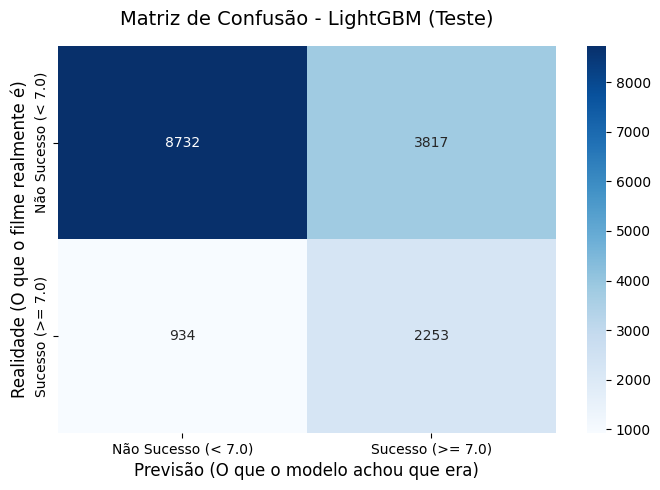

In [69]:
pred_campeao = lgbm.predict(X_test_scaled)
nomes_das_classes = ['Não Sucesso (< 7.0)', 'Sucesso (>= 7.0)']

plt.figure(figsize=(7,5))
sns.heatmap(
    confusion_matrix(y_test, pred_campeao), 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=nomes_das_classes, 
    yticklabels=nomes_das_classes
)

plt.title('Matriz de Confusão - LightGBM (Teste)', fontsize=14, pad=15)
plt.ylabel('Realidade (O que o filme realmente é)', fontsize=12)
plt.xlabel('Previsão (O que o modelo achou que era)', fontsize=12)

plt.tight_layout()
plt.show()

In [70]:
import joblib
import os

print("Re-treinando o Campeão para Produção (com nomes reais)...")

lgbm.fit(X_train, y_train)

caminho_pasta = 'models'
os.makedirs(caminho_pasta, exist_ok=True)
caminho_arquivo = os.path.join(caminho_pasta, 'lgbm_campeao_caudalonga.pkl')
joblib.dump(lgbm, caminho_arquivo)

print(f"✅ Modelo para Produção salvo em: {caminho_arquivo}")
print("As colunas que o modelo memorizou foram:", lgbm.feature_name_)

Re-treinando o Campeão para Produção (com nomes reais)...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 12746, number of negative: 50196
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007245 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 840
[LightGBM] [Info] Number of data points in the train set: 62942, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
✅ Modelo para Produção salvo em: models\lgbm_campeao_caudalonga.pkl
As colunas que o modelo memorizou foram: ['runtime', 'budget', 'mes_lancamento', 'tem_tagline', 'tamanho_sinopse', 'genero_Action', 'genero_Adventure', 'genero_Animation', 'genero_Comedy', 'genero_Crime', 'genero_Documentary', 'genero_Dr